<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="https://www.uoc.edu/content/dam/news/images/noticies/2016/202-nova-marca-uoc.jpg" align="left" width="45%">
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">M2.991 · Aprenentatge automàtic · PAC4</p>
<p style="margin: 0; text-align:right;">2025-2· Màster universitari en Ciència de dades (Data science)</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Estudis d'Informàtica, Multimèdia i Telecomunicació</p>
</div>
</div>
<div style="width:100%;">&nbsp;</div>

# **PAC 4: Combinació de Models**

## Objectiu
Aquesta quarta Pràctica d'Avaluació Contínua (PAC 4) té com a objectiu principal consolidar els coneixements adquirits en les PACs anteriors (introducció a l'aprenentatge automàtic, anàlisi exploratòria de dades, mètodes supervisats i no supervisats) i introduir i aprofundir en tècniques avançades d'Ensemble Learning (Aprenentatge per Conjunts).

Al finalitzar aquesta PAC, hauries de ser capaç de:

* Implementar i comparar diverses tècniques d'ensemble learning (p. ex., Bagging/Random Forest, Boosting -AdaBoost, Gradient Boosting-, Stacking i cascading) sobre un conjunt de dades específic.
* Analitzar i explicar com els hiperparàmetres clau dels mètodes ensemble influeixen en el seu comportament i rendiment.
* Avaluar i comparar la importància de les característiques (feature importance) obtinguda a través de diferents mètodes ensemble.
* Justificar quan i per què un mètode ensemble podria ser preferible a un altre, o a un model individual (connectant amb conceptes com el trade-off sesgo-varianza).
* Aplicar correctament metodologies de validació (com la validació creuada) per a l'avaluació i comparació robusta dels models ensemble.

## Conjunt de dades
L'empresa **CloudSync Platforms** opera un ecosistema de programari B2B al núvol sota un model de subscripció mensual (SaaS). En aquest sector, la retenció d'usuaris és crítica per a la rendibilitat a llarg termini. Recentment, l'equip directiu ha detectat fluctuacions inusuals en les taxes d'abandonament i necessita anticipar-se al comportament de la seva cartera de clients per al pròxim cicle de facturació. Això els permetrà dirigir estratègicament les seves campanyes de retenció i optimitzar l'assignació de recursos en els seus clústers de servidors.

El dataset (`cloudsync_churn_data.csv`) conté 3000 perfils consolidats de clients actius durant l'últim trimestre. L'objectiu de l'equip de Data Science és predir l'estat de la subscripció de l'usuari per al mes següent, el qual es classifica en tres possibles escenaris: el client renova el seu pla (0), el client pausa temporalment el seu compte (1), o el client cancel·la el servei definitivament (2).

La informació proporcionada és el resultat de la unió de múltiples fonts de dades de la companyia: registres tècnics de telemetria del backend, mètriques d'interacció dins de l'aplicació i dades tradicionals de servei al client (CRM). L'equip d'enginyeria de dades adverteix que l'ecosistema de la plataforma és altament complex: existeixen interaccions ocultes entre les variables d'infraestructura i el comportament de l'usuari, i sospiten que els indicadors tradicionals de "satisfacció del client" podrien estar emmascarant els veritables detonants tècnics de l'abandonament.  

L'equip directiu ha estat molt clar respecte a les prioritats d'aquesta iniciativa: el pitjor escenari possible per a la companyia és perdre un client de forma imprevista (cancel·lació definitiva). Des del punt de vista operatiu, prefereixen que l'equip de suport dediqui recursos preventius a un usuari que potser només anava a pausar el seu compte, abans que deixar escapar un client que estava a punt d'abandonar-nos per complet.

Les variables del dataset són les següents:

| Variable Objectiu | Estat  | Descripció |
| :--- | :--- | :--- |
| `subscription_status` | `0` (Renovar) | L'usuari tria continuar amb la seva subscripció activa i se li facturarà normalment el pròxim cicle. |
| `subscription_status` | `1` (Pausar) | L'usuari suspèn temporalment el seu compte, aturant la facturació però conservant el seu perfil i dades per a un possible retorn en el futur. |
| `subscription_status` | `2` (Cancelar) | L'usuari acaba permanentment la seva subscripció i abandona la plataforma (aquest és l'esdeveniment final d'abandonament o *churn* que l'empresa desitja evitar). |

<br>

| Variable Predictora | Descripció |
| :--- | :--- |
| `api_response_time_ms` | El temps mitjà en mil·lisegons que triguen els servidors de l'empresa a processar i respondre a les accions realitzades per l'usuari en l'aplicació. |
| `monthly_ip_variation` | El nombre d'adreces IP distintes des de les quals l'usuari ha iniciat sessió en el seu compte durant els últims 30 dies. |
| `avg_network_latency` | El retard mitjà en mil·lisegons perquè les dades viatgin d'anada i tornada entre el dispositiu de l'usuari i la xarxa del servidor. |
| `unique_active_devices` | El nombre total de dispositius de maquinari distints (smartphones, laptops, tablets) que l'usuari ha utilitzat per accedir al servei aquest mes. |
| `promotional_discount_pct` | El percentatge de descompte aplicat actualment a la tarifa de subscripció mensual estàndard de l'usuari (per exemple, una oferta de retenció del 20%). |
| `days_since_app_update` | El nombre de dies que han transcorregut des que l'usuari va descarregar i instal·lar per última vegada una actualització de versió per al programari/aplicació. |
| `internal_engagement_score` | Una mètrica de producte pròpia (normalment de 0 a 100) calculada per l'empresa per mesurar com de profundament navega l'usuari a través de les funcions de la plataforma. |
| `nps_satisfaction_score` | El Net Promoter Score (normalment de 0 a 10) proporcionat per l'usuari en la seva enquesta de satisfacció del client més recent. |
| `monthly_usage_frequency` | El nombre total de sessions individuals o vegades que l'usuari va obrir i utilitzar activament l'aplicació en l'últim mes. |
| `open_support_tickets` | El nombre actual de sol·licituds de servei al client o suport tècnic sense resoldre enviades per l'usuari. |
| `current_subscription_tier` | El nivell del pla de facturació actiu de l'usuari, que va des de nivells bàsics/gratuïts (1) fins a nivells premium/empresarials (5). |
| `payment_method` | L'instrument financer que l'usuari té registrat actualment per a la facturació recurrent (per exemple, Targeta de Crèdit, PayPal, Transferència Bancària, Cripto). |
| `assigned_server_region` | El centre de dades geogràfic o node de servidor al núvol (per exemple, US-East, EU-Central) que allotja el perfil i les dades principals de l'usuari. |
| `customer_age` | L'edat biològica del client en anys, segons el proporcionat durant el procés de registre. |
| `declared_income` | L'ingrés financer anual estimat declarat per l'usuari en la configuració del seu perfil o en l'enquesta de benvinguda. |
| `email_open_rate` | El percentatge històric de correus electrònics de màrqueting, butlletins i informatius enviats per l'empresa que l'usuari realment obre. |
| `newsletter_clicks` | El nombre total de vegades que l'usuari ha fet clic en els enllaços inclosos en els butlletins setmanals o mensuals de l'empresa. |
| `historical_purchases` | El recompte històric de transaccions distintes, actualitzacions o compres úniques que l'usuari ha realitzat des que va crear el compte. |
| `account_age_days` | El nombre total de dies que han transcorregut des de la data exacta en què l'usuari es va registrar per primera vegada en el servei. |
| `virtual_wallet_balance` | La quantitat actual de crèdit monetari o moneda interna de la plataforma que l'usuari posseeix en el seu compte per a futures compres. |

<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<strong>Nom i cognoms:</strong> Carles Trullàs Fernández
</div>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    recall_score,
    precision_score
 )
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier

from imblearn.ensemble import BalancedRandomForestClassifier

RANDOM_STATE = 42
TARGET_COL = "subscription_status"

## 1 . Càrrega, Anàlisi Exploratòria Crítica i Auditoria de I.A. (1 punt)

<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>1.1. Càrrega i Estructura:</h4>
 Carrega el dataset `cloudsync_churn_data.csv` i realitza una inspecció inicial de la seva estructura (tipos de dades, dimensions i verificació de valors nuls).
</div>

In [2]:
# Carreguem el dataset
df = pd.read_csv("data/cloudsync_churn_data.csv")

print("Dimensions:", df.shape)

with pd.option_context("display.max_columns", None, "display.max_colwidth", None):
    print("\nTipus de dades:")
    display(df.dtypes.to_frame("dtype").T)

    print("\nValors nuls per columna:")
    display(df.isnull().sum().to_frame("n_nulls").T)

    print("\nPrimeres files:")
    display(df.head())

print("\nDistribució de la variable objectiu:")
display(df[TARGET_COL].value_counts().sort_index().to_frame("count").T)

Dimensions: (3000, 21)

Tipus de dades:


,api_response_time_ms,monthly_ip_variation,avg_network_latency,unique_active_devices,days_since_app_update,internal_engagement_score,nps_satisfaction_score,monthly_usage_frequency,open_support_tickets,promotional_discount_pct,current_subscription_tier,customer_age,declared_income,virtual_wallet_balance,email_open_rate,newsletter_clicks,historical_purchases,account_age_days,payment_method,assigned_server_region,subscription_status
dtype,float64,float64,float64,int64,int64,float64,int64,int64,int64,int64,float64,int64,float64,float64,float64,int64,int64,int64,object,object,int64



Valors nuls per columna:


,api_response_time_ms,monthly_ip_variation,avg_network_latency,unique_active_devices,days_since_app_update,internal_engagement_score,nps_satisfaction_score,monthly_usage_frequency,open_support_tickets,promotional_discount_pct,current_subscription_tier,customer_age,declared_income,virtual_wallet_balance,email_open_rate,newsletter_clicks,historical_purchases,account_age_days,payment_method,assigned_server_region,subscription_status
n_nulls,0,150,0,0,0,0,0,0,0,0,150,0,0,0,0,0,0,0,0,0,0



Primeres files:


,api_response_time_ms,monthly_ip_variation,avg_network_latency,unique_active_devices,days_since_app_update,internal_engagement_score,nps_satisfaction_score,monthly_usage_frequency,open_support_tickets,promotional_discount_pct,current_subscription_tier,customer_age,declared_income,virtual_wallet_balance,email_open_rate,newsletter_clicks,historical_purchases,account_age_days,payment_method,assigned_server_region,subscription_status
0,18.615127,7.0,30.069944,8,7,22.606118,2,20,1,0,1.0,55,50058.41,31.70,29.800941,3,5,533,Bank Transfer,Region_16,0
1,57.214215,NaN,109.410786,8,16,79.154274,10,91,0,10,2.0,21,62994.41,104.73,42.198697,6,2,561,PayPal,Region_39,2
2,32.247088,7.0,55.214023,7,10,74.514592,10,43,0,5,1.0,20,52248.29,16.54,14.623551,2,1,106,Credit Card,Region_11,1
3,7.054161,2.0,13.777965,3,14,20.282166,1,59,0,10,1.0,56,34111.91,0.00,12.529304,0,2,562,Bank Transfer,Region_14,0
4,19.782102,1.0,32.648796,3,8,70.395642,0,70,3,0,2.0,24,49210.62,0.00,20.658356,1,1,1936,PayPal,Region_07,0



Distribució de la variable objectiu:


subscription_status,0,1,2
count,1777,925,298


<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Observacions:</h4>

* El dataset té prou volum (3000 registres) per entrenar models supervisats.
* Les classes de la variable objectiu estan bastant desbalancejades.
* Tenim variables numèriques (int i float) i també catagòriques.
* Les columnes monthly_ip_variation i current_subscription_tier tenen valors nuls.
</div>

<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>1.2. Anàlisi Exploratòria (EDA) Comparativa amb I.A.:</h4>
    
* Utilitza una eina d'I.A. Generativa (ChatGPT, Gemini, Claude, etc.) perquè t'expliqui quins solen ser, **segons la teoria del sector SaaS**, els indicadors més comuns que prediuen l'abandonament (*churn*) d'un client.
* Realitza la teva pròpia anàlisi estadística i visual (correlacions, distribucions per classe, etc.) sobre les dades reals proporcionades en aquest exercici.
</div>

,proportion,percentage
subscription_status,,
0,0.592333,59.23
1,0.308333,30.83
2,0.099333,9.93


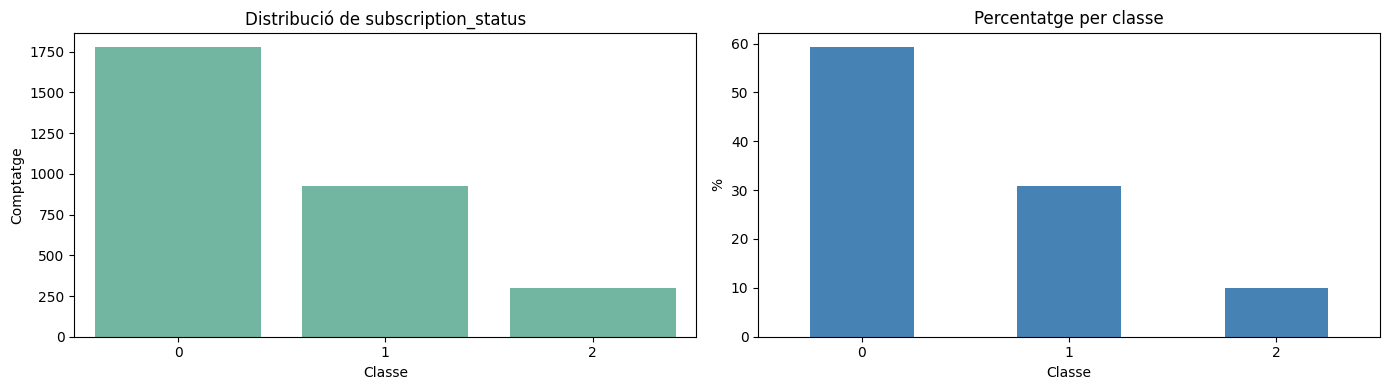

,corr_with_target
monthly_ip_variation,0.789736
avg_network_latency,0.719279
unique_active_devices,0.718942
api_response_time_ms,0.367821
internal_engagement_score,0.122009
days_since_app_update,0.058987
account_age_days,0.044638
customer_age,-0.025985
declared_income,-0.022043
email_open_rate,-0.019197


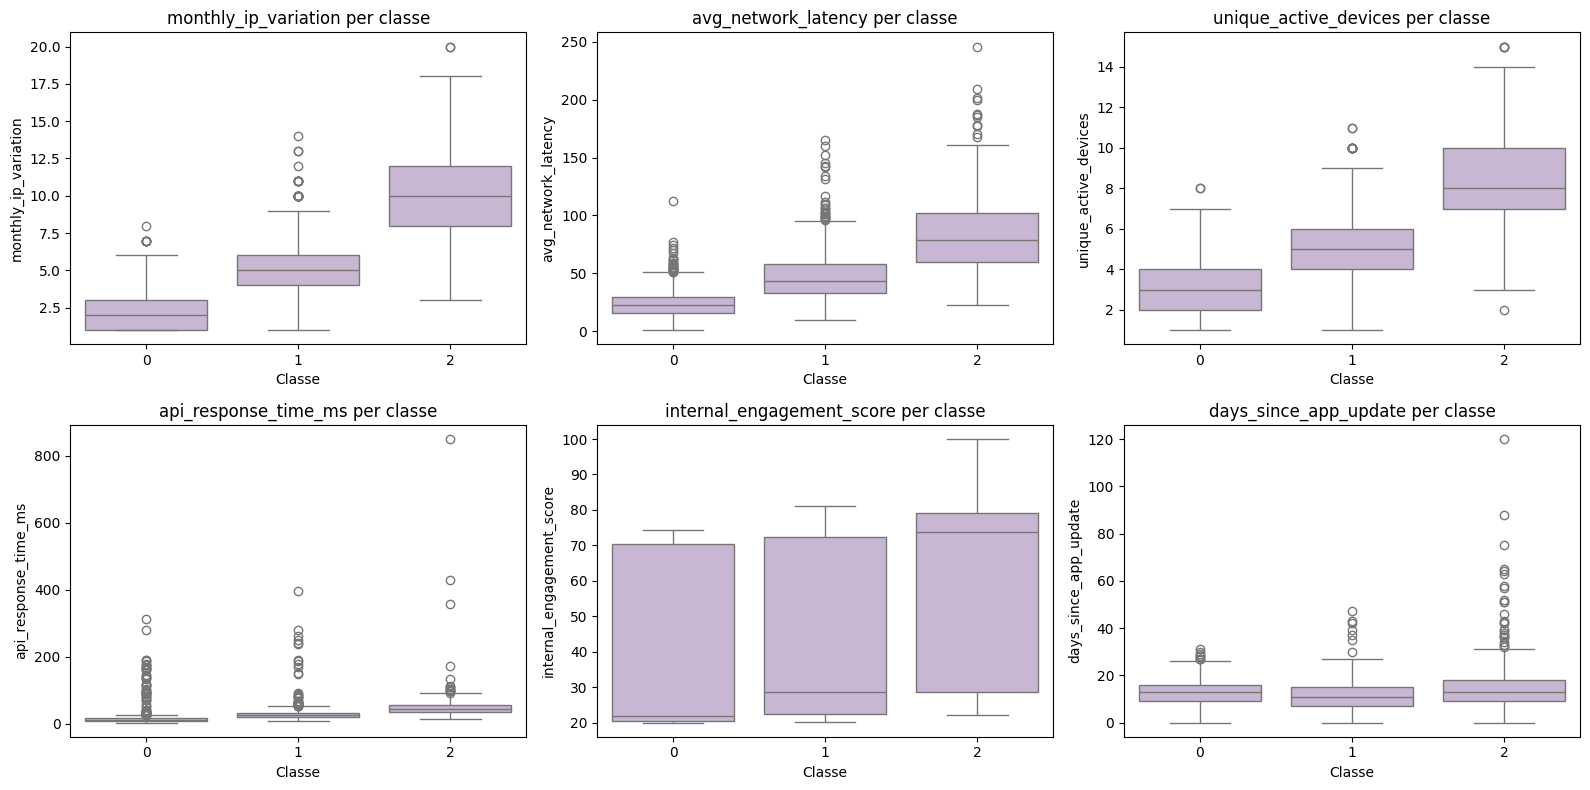

,feature,dispersion_score
0,payment_method,0.000264
1,assigned_server_region,0.000059


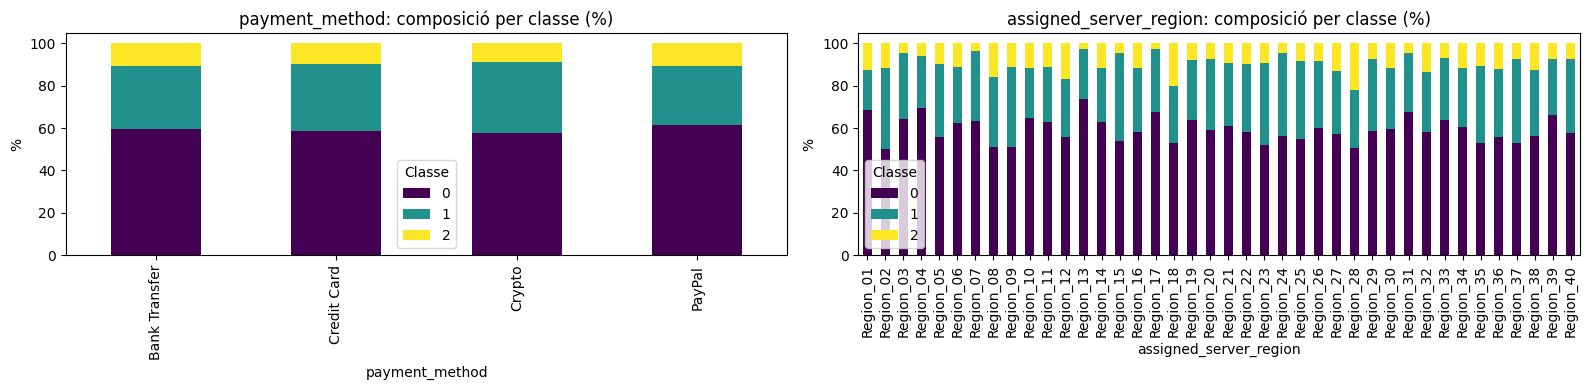

In [3]:
class_distribution = (
    df[TARGET_COL]
    .value_counts(normalize=True)
    .sort_index()
    .rename("proportion")
    .to_frame()
    .assign(percentage=lambda x: (x["proportion"] * 100).round(2))
)
display(class_distribution)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.countplot(data=df, x=TARGET_COL, ax=axes[0], color="#66c2a5")
axes[0].set_title("Distribució de subscription_status")
axes[0].set_xlabel("Classe")
axes[0].set_ylabel("Comptatge")

class_distribution["percentage"].plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Percentatge per classe")
axes[1].set_xlabel("Classe")
axes[1].set_ylabel("%")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

# Correlacions numèriques amb la variable objectiu
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if TARGET_COL in numeric_cols:
    numeric_cols_no_target = [c for c in numeric_cols if c != TARGET_COL]
else:
    numeric_cols_no_target = numeric_cols

corr_with_target = df[numeric_cols_no_target + [TARGET_COL]].corr(numeric_only=True)[TARGET_COL].drop(TARGET_COL).sort_values(key=np.abs, ascending=False)
display(corr_with_target.to_frame("corr_with_target"))

top_num_cols = corr_with_target.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), top_num_cols):
    sns.boxplot(data=df, x=TARGET_COL, y=col, ax=ax, color="#cab2d6")
    ax.set_title(f"{col} per classe")
    ax.set_xlabel("Classe")
plt.tight_layout()
plt.show()

# Variables categòriques: distribució normalitzada per classe
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

if categorical_cols:
    cat_summary = []
    for c in categorical_cols:
        tmp = pd.crosstab(df[c], df[TARGET_COL], normalize="columns")
        dispersion = tmp.var(axis=1).mean()
        cat_summary.append((c, dispersion))

    cat_summary_df = pd.DataFrame(cat_summary, columns=["feature", "dispersion_score"]).sort_values("dispersion_score", ascending=False)
    display(cat_summary_df)

    top_cat = cat_summary_df.head(2)["feature"].tolist()
    fig, axes = plt.subplots(1, len(top_cat), figsize=(8 * len(top_cat), 4))
    if len(top_cat) == 1:
        axes = [axes]
    for ax, c in zip(axes, top_cat):
        pct = pd.crosstab(df[c], df[TARGET_COL], normalize="index") * 100
        pct.plot(kind="bar", stacked=True, ax=ax, colormap="viridis")
        ax.set_title(f"{c}: composició per classe (%)")
        ax.set_ylabel("%")
        ax.legend(title="Classe")
    plt.tight_layout()
    plt.show()

<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Observacions:</h4>  
    
* Li he preguntat a Gemini Pro, i em diu que la teoria SaaS acostuma a posar molt focus en satisfacció, engagement i incidències de suport, que té tot el sentit del món.
* Però si ens mirem les correlacions de les variables d'aquest dataset amb la variable objectiu, veiem que les variables més correlacionades amb la var obj són monthly_ip_variation i avg_network_latency, que són variables més d'aspecte tècnic.
* Si mirem els boxplots, veiem que el monthly_ip_variation dels clients que borren la subscripció és bastant més alta, cosa que té sentit, ja que per exemple podria indicar que el servei no els hi funciona bé i han de provar diversos dispositius. O una altre hipòtesi seria que per qüestions logístiques han d'utilitzar la app en diversos dispositius i no els hi resulta còmode.
* El mateix amb avg_network_latency, ja que la latència dels usuaris que borren la subscipció és més alta, cosa que té tot el sentit del món ja que latència alta implica que la app no funciona tant ràpid, i pot generar malestar.
* La internal_eng_score (com deia Gemini) si que està correlacionada amb la variable objectiu, però molt menys que les que he comentat abans. La correlació de nps_satisfaction_score amb la variable ojectiu és pràcticament 0.
* Un comportament estrany és que si ens fixem, en el boxplot, l'internal_engagement_score per la gent de la classe 2 sembla més alt. És un comportament estrany, la qual cosa ens fa dubtar d'una variable que Gemini ens deia que seria molt important.

</div>

<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>1.3. Anàlisi Crítica d'Evidència:</h4>
    
* Compara les conclusions teòriques proposades per la I.A. amb els patrons reals detectats en el dataset. Existeixen variables que la I.A. considera crítiques però que en aquest dataset mostren poca rellevància o comportaments inesperats?
* Identifica i discuteix els desafiaments específics detectats: desequilibri de classes en la variable `subscription_status`, presència de multicol·linealitat i l'impacte dels *outliers*.
</div>

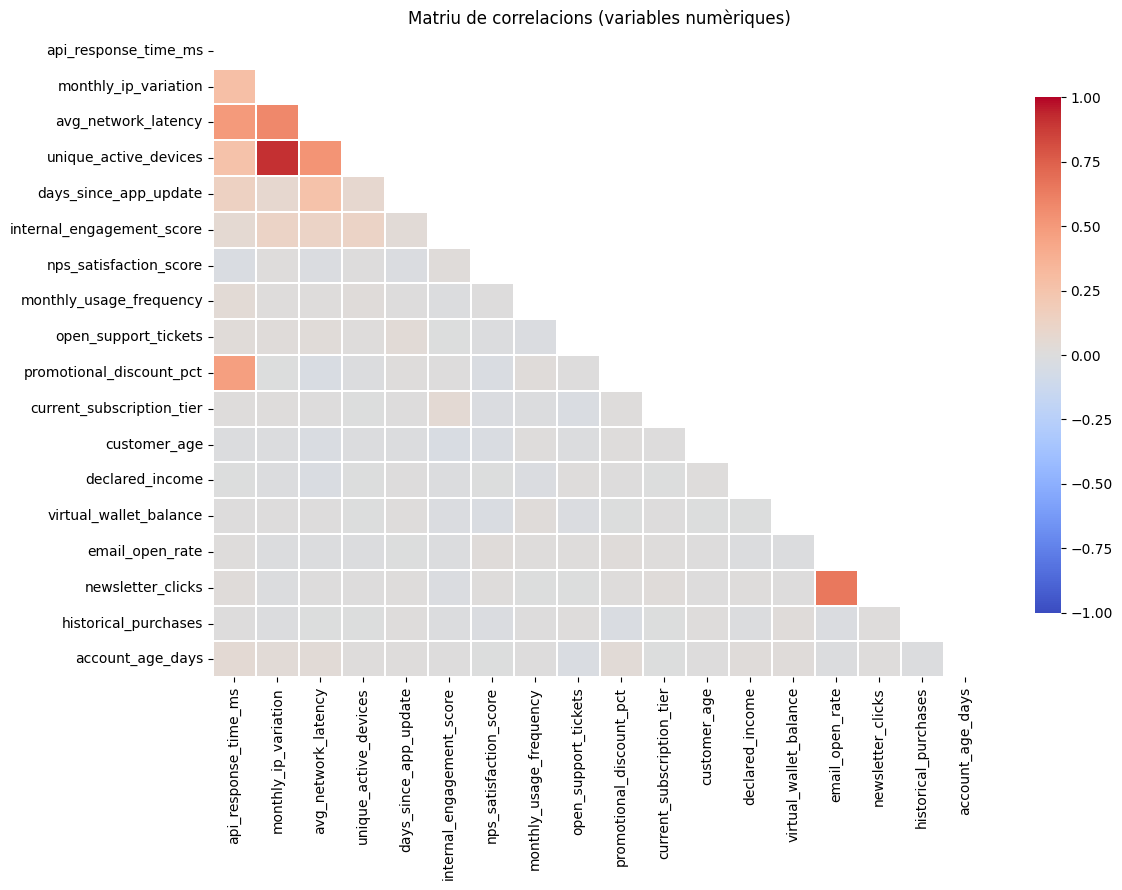

,,corr,abs_corr
monthly_ip_variation,unique_active_devices,0.908547,0.908547


,class_pct
subscription_status,
0,59.23
1,30.83
2,9.93


,outlier_rate_pct
promotional_discount_pct,8.17
api_response_time_ms,7.03
monthly_ip_variation,6.27
virtual_wallet_balance,6.23
avg_network_latency,6.10
unique_active_devices,5.53
open_support_tickets,2.03
days_since_app_update,1.63
customer_age,1.60
historical_purchases,1.10


In [4]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols_wo_target = [c for c in num_cols if c != TARGET_COL]

# Matriu de correlacions entre variables numèriques
corr_matrix = df[num_cols_wo_target].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=False,
    linewidths=0.3,
    cbar_kws={"shrink": 0.8}
)
plt.title("Matriu de correlacions (variables numèriques)")
plt.tight_layout()
plt.show()

# Parelles amb correlació absoluta alta
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = (
    upper.stack()
    .rename("corr")
    .to_frame()
    .assign(abs_corr=lambda x: x["corr"].abs())
    .sort_values("abs_corr", ascending=False)
)
display(high_corr_pairs[high_corr_pairs["abs_corr"] >= 0.70].head(15))

# Distribució de classes
class_pct = (df[TARGET_COL].value_counts(normalize=True).sort_index() * 100).round(2)
display(class_pct.to_frame("class_pct"))

# Taxa d'outliers per variable amb regla IQR
q1 = df[num_cols_wo_target].quantile(0.25)
q3 = df[num_cols_wo_target].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper_lim = q3 + 1.5 * iqr

outlier_mask = (df[num_cols_wo_target] < lower) | (df[num_cols_wo_target] > upper_lim)
outlier_rate = (outlier_mask.mean() * 100).sort_values(ascending=False).round(2)
display(outlier_rate.head(10).to_frame("outlier_rate_pct"))

<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Observacions:</h4>  
    
* El desequilibri de classes és clar (classe 2 minoritària). Això ho gestionarem escollint bé les mètriques d'avaluació del model.
* Les variables tècniques (`monthly_ip_variation`, `avg_network_latency` i `unique_active_devices`) mostren associacions més fortes amb la variable objectiu que alguns indicadors de satisfacció que ens ha proposat Gemini (per ex `nps_satisfaction_score` i `internal_engagement_score`, que tenen associació molt baixa amb la variable objectiu) . Això ens diu que Gemini ha fet una lectura SaaS massa genèrica i reforça la necessitat de validar amb dades del cas real.
* A la matriu de correlacions es detecten parelles amb correlació elevada. Això pot afectar models lineals per inestabilitat de coeficients, però en els models basats en arbres/ensembles solen ser més robustos a aquesta casuística.
* L'anàlisi d'outliers (IQR) mostra valors extrems en variables numèriques rellevants, com per exemple promotional_discount_pct. Els mètodes d'ensemble basats en arbres són robustos a outliers, ja que simplement estableixen talls. Però per mètodes lineals si que s'ha d'anar amb compte.

</div>

<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>1.4. Preparació i Justificació de Dades:</h4>
    
* Realitza les transformacions necessàries per a la classificació: codificació de variables categòriques i eliminació de redundàncies detectades.
* Realitza la divisió Train/Test (80/20) assegurant l'estratificació de la variable objectiu i utilitza la llavor `random_state=42`.

</div>

In [5]:
X = df.drop(columns=[TARGET_COL]).copy()
y = df[TARGET_COL].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Mida train:", X_train.shape, "| Mida test:", X_test.shape)
print("\nDistribució train (%):")
display((y_train.value_counts(normalize=True).sort_index() * 100).round(2).to_frame("train_pct").T)
print("\nDistribució test (%):")
display((y_test.value_counts(normalize=True).sort_index() * 100).round(2).to_frame("test_pct").T)

num_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("\nNumèriques:", len(num_features), "| Categòriques:", len(cat_features))

preprocess_template = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            num_features
        ),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
            ]),
            cat_features
        )
    ]
 )

preprocess_for_meta = clone(preprocess_template)
X_train_meta = preprocess_for_meta.fit_transform(X_train)
X_test_meta = preprocess_for_meta.transform(X_test)
meta_feature_names = preprocess_for_meta.get_feature_names_out()

print("Shape train preprocessat:", X_train_meta.shape)
print("Shape test preprocessat:", X_test_meta.shape)

PRIMARY_SCORING = "f1_macro"
print("Mètrica principal seleccionada:", PRIMARY_SCORING)

Mida train: (2400, 20) | Mida test: (600, 20)

Distribució train (%):


subscription_status,0,1,2
train_pct,59.25,30.83,9.92



Distribució test (%):


subscription_status,0,1,2
test_pct,59.17,30.83,10.0



Numèriques: 18 | Categòriques: 2
Shape train preprocessat: (2400, 62)
Shape test preprocessat: (600, 62)
Mètrica principal seleccionada: f1_macro


<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Observacions:</h4>  
    
* Fem una divisió estratificada 80/20 per mantenir la proporció de classes.
* Fixem `F1-macro` com a mètrica principal perquè tracta totes les classes amb el mateix pes, que és just el que necessitem en un context desbalancejat.

* Per imputar en categòriques, fem servir el most_frequent, tot i que no hi havia nuls en cap variable categòrica.

* Per imputar en numèriques, fem servir la mediana.

* No estem cometent leakage ja que fem fit_transform sobre train i tansform sobre test.

* El preprocessament de les numèriques inclou un scaler. Això pels models d'arbres no cal (tampoc els penalitza), però pels models lineals si que fa falta.

* El preprocessament de les categòriques hem fet ohe. Pels models basats en arbres, amb un label encoder és suficient, però no és convenient fer label encoder per models lineals en el nostre cas, ja que si ho fessim les variables categòriques tindrien un ordre que no seria real (cap de les dues variables categòriqes té un ordre natural en el nostre cas).
</div>

<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>1.5. Anàlisi final:</h4>

* Detalla quina eina d'I.A. has fet servir i enganxa el/s *prompts* principals que vas utilitzar per obtenir el marc teòric inicial.
* Explica quines respostes de la I.A. van resultar ser interpretacions errònies o "al·lucinacions" basades en teoria general en contrastar-les amb la realitat sintètica de CloudSync.
* Què has après de nou en aquest procés de contrast? Quina informació has hagut de buscar més enllà de les suggerències de la I.A. o els materials docents per resoldre els reptes d'aquest dataset?
</div>

<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Observacions:</h4>  
    
* Eina d'IA utilitzada: Gemini Pro.
* Prompt "Quins són els factors més habituals de churn en SaaS B2B?"

* Contrast entre teoria i dades reals:
  - La teoria SaaS general posava el focus en satisfacció, engagement i suport, però a les dades reals les associacions més fortes amb `subscription_status` apareixen en variables tècniques (`monthly_ip_variation`, `avg_network_latency`, `unique_active_devices`).
  - `nps_satisfaction_score` mostra relació molt baixa amb la variable objectiu, i `internal_engagement_score` té un comportament menys directe del que suggeria la teoria.
* Quines "al·lucinacions" o simplificacions ha fet la IA:
  - Assumir patrons SaaS estàndard com si fossin universals.
  - Assumir que més engagement implica automàticament menys churn.
  - Infravalorar el pes de variables d'infra en aquest dataset sintètic.
* Aprenentatges:
  - La IA és útil per generar hipòtesis inicials, però no substitueix la validació amb EDA i mètriques. 

</div>

## 2 . Entrenament i Avaluació de Models Base (1 punt)

<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>Implementació:</h4>

1. Entrena amb el conjunt de dades d'entrenament i valida amb el conjunt de dades de validació els següents models base (Desa les prediccions per al seu ús més endavant):
   * Regressió Logística (`LogisticRegression`)
   * Arbre de Decisió (`DecisionTreeClassifier`)
   * K veïns més propers (`KNeighborsClassifier`)
   * Classificador Naïves-Bayes (`GaussianNB`)
2. Per a cada model, reporta les mètriques obtingudes de la validació que consideris necessàries.
3. **Anàlisi Crítica:** Comenta breument el rendiment dels models base. Quina de les mètriques consideres més informativa per avaluar el rendiment i per què? Justifica la teva resposta.
   
</div>

In [6]:
def build_pipeline(estimator):
    return Pipeline(steps=[
        ("preprocess", clone(preprocess_template)),
        ("model", estimator)
    ])

def evaluate_predictions(y_true, y_pred, model_name):
    p2, r2, f2, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=[2], average=None, zero_division=0
    )

    row = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
        "precision_class_2": p2[0],
        "recall_class_2": r2[0],
        "f1_class_2": f2[0],
        "recall_macro": recall_score(y_true, y_pred, average="macro"),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
    }

    print(f"\n===== {model_name} =====")
    print(classification_report(y_true, y_pred, digits=4))
    return row

In [7]:
base_models = {
    "LogisticRegression": LogisticRegression(max_iter=4000, random_state=RANDOM_STATE),
    "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
    "GaussianNB": GaussianNB()
}

base_trained_models = {}
base_predictions = {}
base_results = []

for name, estimator in base_models.items():
    pipe = build_pipeline(estimator)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    base_trained_models[name] = pipe
    base_predictions[name] = y_pred
    base_results.append(evaluate_predictions(y_test, y_pred, name))

base_results_df = pd.DataFrame(base_results).sort_values("f1_macro", ascending=False)
print("\nResultats comparatius models base:")
display(base_results_df.style.format({
    "accuracy": "{:.4f}",
    "f1_macro": "{:.4f}",
    "f1_weighted": "{:.4f}",
    "precision_class_2": "{:.4f}",
    "recall_class_2": "{:.4f}",
    "f1_class_2": "{:.4f}",
    "recall_macro": "{:.4f}",
    "precision_macro": "{:.4f}"
}))


===== LogisticRegression =====
              precision    recall  f1-score   support

           0     0.9054    0.9437    0.9241       355
           1     0.8263    0.7459    0.7841       185
           2     0.7937    0.8333    0.8130        60

    accuracy                         0.8717       600
   macro avg     0.8418    0.8410    0.8404       600
weighted avg     0.8699    0.8717    0.8698       600


===== DecisionTree =====
              precision    recall  f1-score   support

           0     0.9027    0.8620    0.8818       355
           1     0.6497    0.6919    0.6702       185
           2     0.6094    0.6500    0.6290        60

    accuracy                         0.7883       600
   macro avg     0.7206    0.7346    0.7270       600
weighted avg     0.7953    0.7883    0.7913       600


===== KNN =====
              precision    recall  f1-score   support

           0     0.8111    0.9437    0.8724       355
           1     0.6824    0.5459    0.6066       185


,model,accuracy,f1_macro,f1_weighted,precision_class_2,recall_class_2,f1_class_2,recall_macro,precision_macro
0,LogisticRegression,0.8717,0.8404,0.8698,0.7937,0.8333,0.8130,0.8410,0.8418
1,DecisionTree,0.7883,0.7270,0.7913,0.6094,0.6500,0.6290,0.7346,0.7206
2,KNN,0.7800,0.7085,0.7679,0.8205,0.5333,0.6465,0.6743,0.7714
3,GaussianNB,0.6300,0.5623,0.6476,0.3333,0.6500,0.4407,0.6118,0.5520


<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Observacions i Anàlisi Crítica:</h4>  

* Els models base donen una línia base útil, però es veu ràpid que en un problema multiclasse desbalancejat hi ha diferències importants entre el rendiment global i rendiment a la classe 2, que és la classe minoritària al dataset (i la més important de cara a negoci).
* La mètrica més informativa aquí és `F1-macro` (mitjana del F1 de les 3 classes, sense ponderar), perquè obliga el model a comportar-se bé a totes les classes i no només a la majoritària. A més, `F1` és una combiació entre precision i recall.
* També s'ha mirat específicament el `recall` de la classe 2, ja que és la classe de més risc per negoci (no se'ns pot ecapar cap usuari que vulgui donar-se de baixa, ja que l'haurem d'intenar retenir amb accions comercials).

</div>

## 3 . Combinació paral·lela de classificadors de base similar: Bagging (1.5 punts)

<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>Implementació:</h4>

1. Implementa `RandomForestClassifier`.
2. Realitza una cerca i ajust (tuning) d'hiperparàmetres clau (n_estimators, max_depth, max_features) utilitzant validació creuada (ex., GridSearchCV o RandomizedSearchCV amb 5-CV). Defineix un rang de cerca raonable per a cada hiperparàmetre i usa la mètrica que vas justificar com a més informativa en el punt anterior per a l'optimització.
3. Reporta els millors hiperparàmetres trobats i l'score de validació creuada obtingut amb ells.
   
</div>

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_pipe = build_pipeline(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
)

rf_param_dist = {
    "model__n_estimators": [200, 300, 500, 700],
    "model__max_depth": [None, 8, 12, 16, 24],
    "model__max_features": ["sqrt", "log2", 0.5, 0.7],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__class_weight": [None, "balanced"]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=rf_param_dist,
    n_iter=24,
    scoring=PRIMARY_SCORING,
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0
)

rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

print("Millors hiperparàmetres RF:")
display(pd.DataFrame([rf_search.best_params_]))
print(f"Best CV score ({PRIMARY_SCORING}): {rf_search.best_score_:.4f}")

Millors hiperparàmetres RF:


,model__n_estimators,model__min_samples_split,model__min_samples_leaf,model__max_features,model__max_depth,model__class_weight
0,300,10,1,sqrt,24,balanced


Best CV score (f1_macro): 0.8257


<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Anàlisi:</h4>  

* Els millors params trobats (`n_estimators=300`, `max_depth=24`, `class_weight=balanced`, `max_features=sqrt`, `min_samples_split=10`, `min_samples_leaf=1`) indiquen un bosc prou gran i profund, però amb una regularització moderada via `min_samples_split` i mostreig de variables per arbre.
* En aquest context desbalancejat, l'elecció de `class_weight=balanced` és clau, ja k el model penalitza més els errors de la classe minoritària (classe 2) i evita que la classe majoritària domini.
* Amb validació creuada de 5 folds, el millor resultat és `F1-macro = 0.8257`. Com ja he comentat, hem triat aquesta mètrica per equilibrar el rendiment entre classes.

</div>

<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>Implementació:</h4>

4. Valida (amb el conjunt de dades de validació) el model Random Forest final (entrenat amb els millors hiperparàmetres sobre tot el set d'entrenament).
5. Mostra un gràfic de la importància de les característiques (feature_importance_) del model final
6. **Anàlisi Crítica:** Compara el rendiment del teu Random Forest optimitzat amb els models base (refereix-te als valors específics de les mètriques que vas obtenir). Va aconseguir RF una millora substancial, especialment en les classes minoritàries? Analitza el teu gràfic d'importància de característiques: Quines variables semblen ser les més rellevants segons RF? Té sentit aquest resultat? Identifica RF algunes de les variables categòriques que s'havien identificat com a importants?
   
</div>


===== RandomForest_optimized =====
              precision    recall  f1-score   support

           0     0.9429    0.9296    0.9362       355
           1     0.8138    0.8270    0.8204       185
           2     0.8065    0.8333    0.8197        60

    accuracy                         0.8883       600
   macro avg     0.8544    0.8633    0.8587       600
weighted avg     0.8894    0.8883    0.8888       600



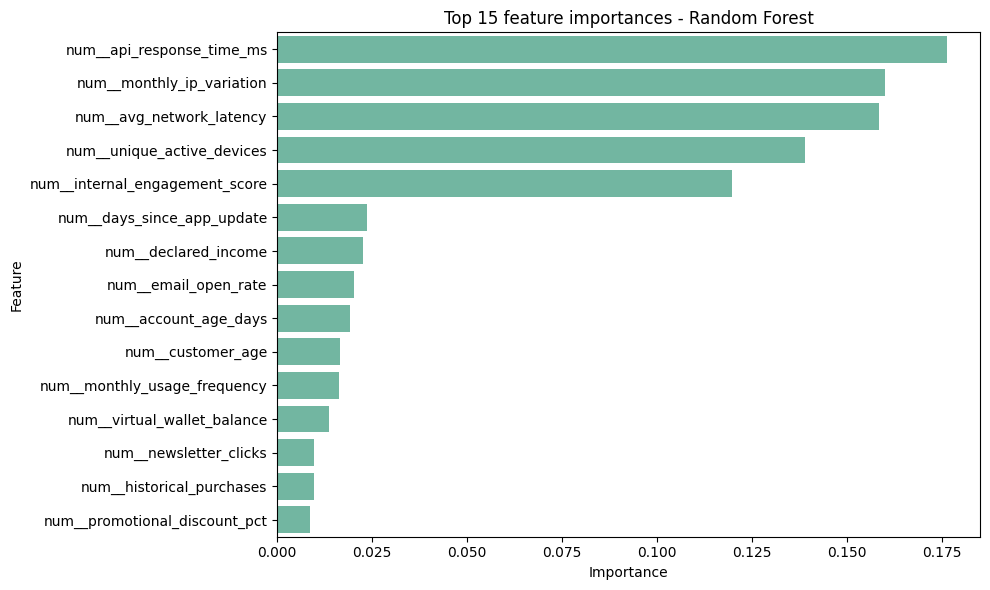

,importance
num__api_response_time_ms,0.176177
num__monthly_ip_variation,0.159990
num__avg_network_latency,0.158435
num__unique_active_devices,0.139009
num__internal_engagement_score,0.119768
num__days_since_app_update,0.023501
num__declared_income,0.022551
num__email_open_rate,0.020268
num__account_age_days,0.019195
num__customer_age,0.016536


In [9]:
rf_pred = best_rf.predict(X_test)
rf_metrics = evaluate_predictions(y_test, rf_pred, "RandomForest_optimized")

# Guardem resultats per a la comparativa final
ensemble_results = []
ensemble_results.append({
    "model": "RandomForest_optimized",
    **{k: v for k, v in rf_metrics.items() if k != "model"}
})

# Feature importance
rf_preprocess = best_rf.named_steps["preprocess"]
rf_model = best_rf.named_steps["model"]
rf_feature_names = rf_preprocess.get_feature_names_out()
rf_importances = pd.Series(rf_model.feature_importances_, index=rf_feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=rf_importances.head(15).values, y=rf_importances.head(15).index, color="#66c2a5")
plt.title("Top 15 feature importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

display(rf_importances.head(15).to_frame("importance"))

<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Observacions i Anàlisi Crítica:</h4>  

* **Comparativa amb models base:** El RF millora el millor model base (LogisticRegression) en `accuracy` (**0.8883** vs **0.8717**), `F1-macro` (**0.8587** vs **0.8404**), `F1-weighted` (**0.8888** vs **0.8698**) i `recall_macro` (**0.8633** vs **0.8410**). Respecte a la resta de models base (DT, KNN, GNB), la millora és clarament superior en totes les mètriques globals.

* **Millora en classes minoritàries (classe 2):** el `recall_class_2` queda a **0.8333**, igual que LR, però RF puja `precision_class_2` (**0.8065** vs **0.7937**) i `F1_class_2` (**0.8197** vs **0.8130**). Per tant, la millora en la classe minoritària és **moderada però realment existeix**: manté detecció alta i redueix falsos positius.

* **Feat importance (RF):** les variables més rellevants són sobretot tècniques i d'ús: `api_response_time_ms` (0.176), `monthly_ip_variation` (0.160), `avg_network_latency` (0.158), `unique_active_devices` (0.139) i `internal_engagement_score` (0.120).

* **Té sentit aquest resultat?** Sí. És coherent amb l'EDA previ: en aquest dataset el senyal de churn està més relacionat amb temes tècnics (latència/temps de resposta/variabilitat d'accés) que amb indicadors tradicionals de satisfacció com indicaba Gemini.

* **Variables categòriques importants:** RF n'identifica algunes, però amb pes baix en el top (`assigned_server_region_Region_28`, `assigned_server_region_Region_18`, importàncies petites de ~0.0036 i ~0.0027). Això indica que les categòriques aporten informació, però en aquest cas les més importants són les variables numèriques.

</div>

## 4 . Combinació paral·lela de classificadors de base similar: Boosting (1.5 punts)

<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>Implementació:</h4>

1. Implementa `GradientBoostingClassifier`.
2. Realitza una cerca i ajust (tuning) d'hiperparàmetres clau utilitzant validació creuada. Defineix un rang de cerca raonable per a cada hiperparàmetre i usa la mètrica F1 seleccionada.
3. Reporta els millors hiperparàmetres trobats i l'score de validació creuada obtingut amb ells.
   
</div>

In [10]:
gb_pipe = build_pipeline(
    GradientBoostingClassifier(random_state=RANDOM_STATE)
 )

gb_param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "model__max_depth": [2, 3, 4, 5],
    "model__subsample": [0.7, 0.85, 1.0],
    "model__min_samples_leaf": [1, 2, 4, 8]
}

gb_search = RandomizedSearchCV(
    estimator=gb_pipe,
    param_distributions=gb_param_dist,
    n_iter=24,
    scoring=PRIMARY_SCORING,
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0
 )

gb_search.fit(X_train, y_train)
best_gb = gb_search.best_estimator_

print("Millors hiperparàmetres Gradient Boosting:")
display(pd.DataFrame([gb_search.best_params_]))
print(f"Best CV score ({PRIMARY_SCORING}): {gb_search.best_score_:.4f}")

Millors hiperparàmetres Gradient Boosting:


,model__subsample,model__n_estimators,model__min_samples_leaf,model__max_depth,model__learning_rate
0,0.7,100,1,2,0.1


Best CV score (f1_macro): 0.8275


<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Anàlisi:</h4>  

* El tuning de BG ha donat un **millor score de CV (F1-macro) de 0.8275**, lleugerament superior al de RF en CV (0.8257).
* Els hiperparàmetres guanyadors (`n_estimators=100`, `learning_rate=0.1`, `max_depth=2`, `min_samples_leaf=1`, `subsample=0.7`) apunten a un boosting **moderat i regularitzat**: arbres poc profunds (ajuda contra overfitting), taxa d'aprenentatge intermèdia i subsampling per reduir variància i millorar generalització.

</div>

<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>Implementació:</h4>

4. Valida (amb el conjunt de dades de validació) el model final.
5. Mostra un gràfic de la importància de les característiques d'aquest model.
6. **Anàlisi Crítica:** Compara el rendiment del teu Gradient Boosting optimitzat amb els models anteriors. Va aconseguir una millora substancial? Analitza el teu gràfic d'importància de característiques: Existeixen diferències notables en el rànquing o en les variables considerades més importants pels models boosting en comparació amb Random Forest?
   
</div>


===== GradientBoosting_optimized =====
              precision    recall  f1-score   support

           0     0.9322    0.9296    0.9309       355
           1     0.8108    0.8108    0.8108       185
           2     0.8197    0.8333    0.8264        60

    accuracy                         0.8833       600
   macro avg     0.8542    0.8579    0.8560       600
weighted avg     0.8835    0.8833    0.8834       600



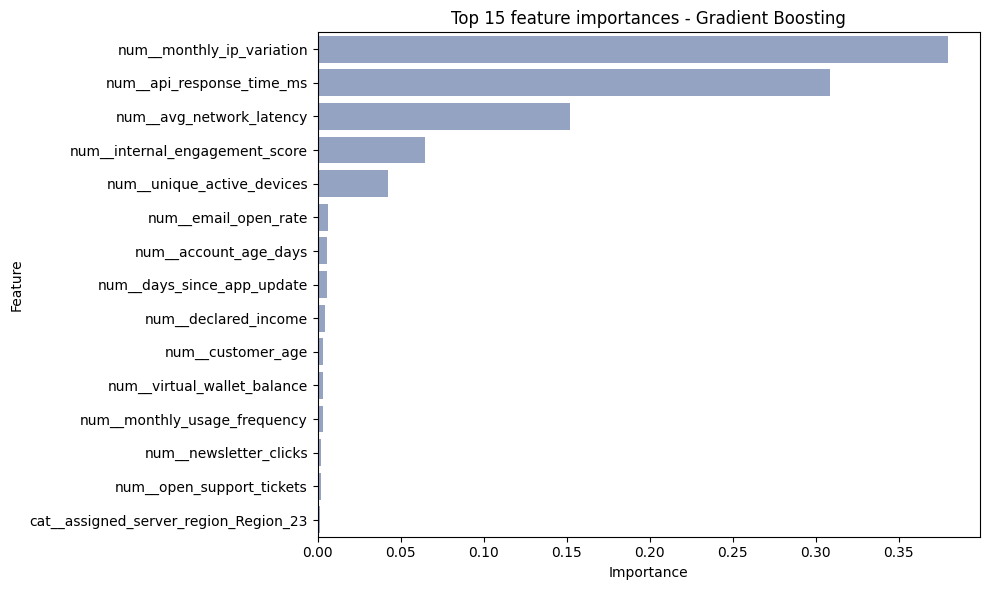

,importance
num__monthly_ip_variation,0.379867
num__api_response_time_ms,0.308668
num__avg_network_latency,0.151934
num__internal_engagement_score,0.064505
num__unique_active_devices,0.042243
num__email_open_rate,0.005942
num__account_age_days,0.005819
num__days_since_app_update,0.005490
num__declared_income,0.004357
num__customer_age,0.003137


In [11]:
gb_pred = best_gb.predict(X_test)
gb_metrics = evaluate_predictions(y_test, gb_pred, "GradientBoosting_optimized")

ensemble_results.append({
    "model": "GradientBoosting_optimized",
    **{k: v for k, v in gb_metrics.items() if k != "model"}
})

gb_preprocess = best_gb.named_steps["preprocess"]
gb_model = best_gb.named_steps["model"]
gb_feature_names = gb_preprocess.get_feature_names_out()
gb_importances = pd.Series(gb_model.feature_importances_, index=gb_feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=gb_importances.head(15).values, y=gb_importances.head(15).index, color="#8da0cb")
plt.title("Top 15 feature importances - Gradient Boosting")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

display(gb_importances.head(15).to_frame("importance"))

<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Observacions i Anàlisi Crítica:</h4>  

* **Comparem amb RF:** en test, GB queda lleugerament per sota de RF en mètriques globals (`F1-macro`: **0.8560** vs **0.8587**, `accuracy`: **0.8833** vs **0.8883**, `recall_macro`: **0.8579** vs **0.8633**).
* **Classe minoritària (classe 2):** GB manté el mateix `recall_class_2` que RF (**0.8333**), però millora `precision_class_2` (**0.8197** vs **0.8065**) i `F1_class_2` (**0.8264** vs **0.8197**). Això indica menys falsos positius en la classe crítica, mantenint capacitat de detecció.
* **Diferències d'importància de variables amb RF:** en GB, el pes queda més concentrat en poques variables (`monthly_ip_variation` 0.380, `api_response_time_ms` 0.309, `avg_network_latency` 0.152), mentre que RF reparteix més la importància entre més predictors. Aquest patró és coherent amb la naturalesa seqüencial de boosting, que tendeix a focalitzar-se en els predictors amb més capacitat de decidir.
* **Variables categòriques:** sí que apareixen en el top20 (p. ex. diverses categories de `assigned_server_region`), però amb pes molt baix (~0.0013-0.0015). Per tant, també en GB el senyal principal continua sent numèric.

</div>

## 5 . Combinació seqüencial de classificadors de base diferent: Stacking (1.5 punt)

<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>Implementació:</h4>

1. Implementa `StackingClassifier`.
2. Utilitza els models base implementats en la secció 2. Creus que aquesta combinació de models és diversa i adequada per a Stacking?
3. Tria un meta-classificador. Pots optar per utilitzar els hiperparàmetres per defecte o realitzar un petit ajust si ho consideres necessari.
4. Valida el `StackingClassifier` complet utilitzant les dades de validació amb la mètrica F1 seleccionada. Reporta l'score.
5. **Anàlisi Crítica:** Compara el rendiment del teu Stacking model amb el millor resultat que vas obtenir d'un ensemble individual (RF o Boosting) en els passos anteriors. Va aportar Stacking una millora significativa del rendiment en aquest dataset? Explica breument com creus que el meta-classificador està utilitzant les prediccions dels teus base learners triats.
   
</div>

In [12]:
stack_estimators = [
    ("lr", build_pipeline(LogisticRegression(max_iter=4000, random_state=RANDOM_STATE))),
    ("dt", build_pipeline(DecisionTreeClassifier(max_depth=10, min_samples_leaf=3, random_state=RANDOM_STATE))),
    ("knn", build_pipeline(KNeighborsClassifier(n_neighbors=15, weights="distance"))),
    ("gnb", build_pipeline(GaussianNB()))
]

stack_meta = LogisticRegression(max_iter=4000, class_weight="balanced", random_state=RANDOM_STATE)

# passthrough=False: només les prediccions dels base learners arriben al meta-learner.
# Això concorda perfectament amb la definició de cascading.
stack_model = StackingClassifier(
    estimators=stack_estimators,
    final_estimator=stack_meta,
    cv=5,
    n_jobs=-1,
    passthrough=False
)

stack_model.fit(X_train, y_train)
stack_pred = stack_model.predict(X_test)
stack_metrics = evaluate_predictions(y_test, stack_pred, "Stacking")

ensemble_results.append({
    "model": "Stacking",
    **{k: v for k, v in stack_metrics.items() if k != "model"}
})


===== Stacking =====
              precision    recall  f1-score   support

           0     0.9312    0.9155    0.9233       355
           1     0.7811    0.7135    0.7458       185
           2     0.6463    0.8833    0.7465        60

    accuracy                         0.8500       600
   macro avg     0.7862    0.8374    0.8052       600
weighted avg     0.8564    0.8500    0.8509       600



<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Observacions i Anàlisi Crítica:</h4>  

* Penso que la combinació de base learners és diversa i adequada per fer stacking (combinem models lineals, arbres, de distància i probabilístics).
* Tot i així, en aquest cas **stacking no supera el millor ensemble individual**: `F1-macro` = **0.8052** (vs **0.8587** RF i **0.8560** GB) i `accuracy` = **0.8500** (vs **0.8883** RF i **0.8833** GB). Per tant, hem perdut rendiment.
* Compte! On sí aporta valor és en recall de la classe crítica: `recall_class_2` = **0.8833**, superior a RF/GB (**0.8333**). Però el cost és una caiguda de `precision_class_2` a **0.6463** i `F1_class_2` a **0.7465**, indicant més falsos positius.
* Podem concloure que la LR final està combinant les sortides dels models base de forma més conservadora cap a detectar classe 2 (prioritza recall), però això penalitza la precision de la classe 2. Per tant, si negoci vol prioritzar detecció agressiva de cancel·lacions i accepta més falses alarmes, podria inclús ser preferible a RF/GB.

</div>

## 6 . Combinació seqüencial de classificadors de base diferent: Cascading (1.5 punts)

<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>Implementació:</h4>

1. Combina en cascada els models base implementats en la secció 2. Tingues en compte la definició presentada en el document "Combinació de models - PID_00296757, Jordi Casas Roma i Julià Minguillón Alfonso" que es troba en els recursos de l'assignatura. Explora un Stacking amb `passthrough=True`. Creus que aquesta combinació de models és diversa i adequada per a Cascading?
2. Tria un meta-classificador. Pots optar per utilitzar els hiperparàmetres per defecte o realitzar un petit ajust si ho consideres necessari.
3. Valida el teu classificador en cascada complet utilitzant les dades de validació amb la mètrica seleccionada. Reporta l'score.
4. **Anàlisi Crítica:** Compara el rendiment del teu model en cascada amb el millor resultat obtingut en els passos anteriors. Va aportar Cascading una millora significativa del rendiment en aquest dataset? Vas observar algun avantatge en termes d'eficiència computacional?
   
</div>

In [13]:
# Definim els estimadors base
stack_estimators = [
    ("lr", build_pipeline(LogisticRegression(max_iter=4000, random_state=RANDOM_STATE))),
    ("dt", build_pipeline(DecisionTreeClassifier(max_depth=10, min_samples_leaf=3, random_state=RANDOM_STATE))),
    ("knn", build_pipeline(KNeighborsClassifier(n_neighbors=15, weights="distance"))),
    ("gnb", build_pipeline(GaussianNB()))
]

# En aquest cas, com que el meta-learner rep també les variables dels meta
# learners, hem de definir un preprocessador pel meta-learner que sàpiga gestionar-ho.

# Guardem la referència només de les categòriques
num_cols_originals = X_train.shape[1]
cat_indices_originals = [X_train.columns.get_loc(col) for col in cat_features]

def select_cat_dinamic(X):
    offset = X.shape[1] - num_cols_originals
    return [idx + offset for idx in cat_indices_originals]

# Definim el pipeline per les variables numèriques
num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Definim el preprocessor pel meta model. Observem que les prediccions dels
# base learners són variables numèriques, i per tant els hi apliquem num_pipeline
# abans de passar-les al meta-learner.
meta_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
            ]),
            select_cat_dinamic  # Busquem només on han quedat les categòriques
        )
    ],
    # Tot allò que no hagi estat atrapat per la regla anterior, va aquí
    remainder=num_pipeline
)

# Arquitectura final del metamodel
cascade_meta = Pipeline([
    ("preprocessor", meta_preprocessor),
    ("classifier", LogisticRegression(max_iter=4000, class_weight="balanced", random_state=RANDOM_STATE))
])

# Model de cascading (stacking amb passthrough=True)
cascade_model = StackingClassifier(
    estimators=stack_estimators,
    final_estimator=cascade_meta,
    cv=5,
    n_jobs=-1,
    passthrough=True
)

cascade_model.fit(X_train, y_train)
cascade_pred = cascade_model.predict(X_test)
cascade_metrics = evaluate_predictions(y_test, cascade_pred, "Cascading_passthrough")

ensemble_results.append({
    "model": "Cascading_passthrough",
    **{k: v for k, v in cascade_metrics.items() if k != "model"}
})


===== Cascading_passthrough =====
              precision    recall  f1-score   support

           0     0.9294    0.8901    0.9094       355
           1     0.7356    0.6919    0.7131       185
           2     0.6047    0.8667    0.7123        60

    accuracy                         0.8267       600
   macro avg     0.7566    0.8162    0.7783       600
weighted avg     0.8372    0.8267    0.8291       600



<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Observacions i Anàlisi Crítica:</h4>  

* Amb `passthrough=True`, el meta-model rep tant les prediccions dels base learners com les característiques d'entrada preprocessades. Això amplia la informació disponible, però també incrementa el risc de sobreajust i de soroll en la decisió final.
* **Resultat obtingut:** `accuracy = 0.8267`, `F1-macro = 0.7783`, `F1-weighted = 0.8291` i `recall_macro = 0.8162`.
* **Classe crítica (2):** `recall_class_2 = 0.8667` (alt), però amb `precision_class_2 = 0.6047` i `F1_class_2 = 0.7123`. Per tant detecta molts casos de risc però amb força falses alarmes.
* **Comparativa amb Stacking:** no hi ha millora en `recall_class_2` (passa de **0.8833** a **0.8667**), i també empitjora el `F1_class_2` (**0.7465** a **0.7123**).
* **Comparativa amb els millors models anteriors:** queda clarament per sota de `RandomForest_optimized` (`F1-macro = 0.8587`) i `GradientBoosting_optimized` (`F1-macro = 0.8560`). També queda per sota de l'Stacking (`F1-macro = 0.8052`).
* Per tant, en aquest dataset, el Cascading no aporta millora significativa del rendiment global.

</div>

## 7 . Alternativa: Balanced Random Forest (1 punt)

El BalancedRandomForestClassifier és una variant de l'algorisme d'encaix Random Forest dissenyada específicament per abordar problemes de classificació amb classes severament desbalancejades sense necessitat de pre-processament extern (com SMOTE).

Mecanisme de Funcionament: La diferència fonamental respecte al Random Forest estàndard resideix a l'etapa de construcció de cada arbre de decisió individual (procés de bootstrapping):

Submostreig Dinàmic: Per entrenar cada arbre del bosc, l'algorisme genera un subconjunt de dades temporal. En aquest pas, fa un submostreig aleatori (random undersampling) de la classe majoritària per igualar el nombre d'instàncies de la classe minoritària.

Entrenament Equilibrat: Com a resultat, cada arbre individual s'entrena amb un dataset perfectament balancejat (ràtio 1:1), encara que el dataset original estigui descompensat.

Agregació: Finalment, el model combina les prediccions de tots els arbres (que han vist diferents subconjunts equilibrats de la classe majoritària) mitjançant una votació per generar la predicció final.

Avantatge Principal: Permet aprofitar la robustesa del bagging (reducció de variància) mentre mitiga el biaix cap a la classe majoritària de forma nativa, explorant una varietat més gran de dades de la classe majoritària a través dels múltiples arbres.

<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>Implementació:</h4>

1. Implementa `BalancedRandomForestClassifier` de la llibreria `imblearn`.
2. Entrena i valida el classificador complet utilitzant la mètrica seleccionada. Reporta l'score.
5. **Anàlisi Crítica:** Compara el rendiment d'aquest model amb els anteriors. Diries que aquest model és més "intel·ligent" o simplement més "agressiu" disparant alarmes?
</div>

In [14]:
brf_pipe = build_pipeline(
    BalancedRandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
)

brf_param_dist = {
    "model__n_estimators": [200, 300, 500, 700],
    "model__max_depth": [None, 8, 12, 16, 24],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__sampling_strategy": ["all", "not minority", "auto"],
    "model__replacement": [False, True]
}

brf_search = RandomizedSearchCV(
    estimator=brf_pipe,
    param_distributions=brf_param_dist,
    n_iter=20,
    scoring=PRIMARY_SCORING,
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0
)

brf_search.fit(X_train, y_train)
brf_model = brf_search.best_estimator_

print("Millors hiperparàmetres Balanced RF:")
display(pd.DataFrame([brf_search.best_params_]))
print(f"Best CV score ({PRIMARY_SCORING}): {brf_search.best_score_:.4f}")

brf_pred = brf_model.predict(X_test)
brf_metrics = evaluate_predictions(y_test, brf_pred, "BalancedRandomForest")

ensemble_results.append({
    "model": "BalancedRandomForest",
    **{k: v for k, v in brf_metrics.items() if k != "model"}
})

Millors hiperparàmetres Balanced RF:


,model__sampling_strategy,model__replacement,model__n_estimators,model__min_samples_split,model__min_samples_leaf,model__max_depth
0,all,True,300,10,2,24


Best CV score (f1_macro): 0.8171

===== BalancedRandomForest =====
              precision    recall  f1-score   support

           0     0.9521    0.8958    0.9231       355
           1     0.7749    0.8000    0.7872       185
           2     0.7200    0.9000    0.8000        60

    accuracy                         0.8667       600
   macro avg     0.8157    0.8653    0.8368       600
weighted avg     0.8742    0.8667    0.8689       600



<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Observacions i Anàlisi Crítica:</h4>  

* **Best CV score:** `F1-macro = 0.8171`.
* **Resultat en test:** `accuracy = 0.8667`, `F1-macro = 0.8368`, `F1-weighted = 0.8689`, `recall_macro = 0.8653`.
* **Classe crítica (2):** `recall_class_2 = 0.9000` (el més alt), amb `precision_class_2 = 0.7200` i `F1_class_2 = 0.8000`.
* **Comparativa amb RF/GB:** no supera el rendiment global de `RandomForest_optimized` (`F1-macro = 0.8587`) ni de `GradientBoosting_optimized` (`F1-macro = 0.8560`), però sí millora clarament el recall de la classe minoritària.
* Conclusió: és un model més agressiu detectant la classe 2 (més recall). Pot ser útil si el negoci prioritza no escapar cancel·lacions encara que augmentin els falsos positius.

</div>

## 8 . Ajustament del Llindar de Decisió (1 punt)

A CloudSync, perdre un client corporatiu per problemes de latència (Classe 2) suposa una pèrdua estimada de 2.000€ (Customer Lifetime Value). D'altra banda, desplegar una intervenció proactiva de suport tècnic VIP (auditoria de xarxa, trucada directa) té un cost operatiu de només 50€. Per tant, és preferible assumir falses alarmes operatives abans que ignorar un client a punt de cancel·lar. Per defecte, els models multiclasse assignen la categoria guanyadora basant-se en la probabilitat més alta (argmax). Utilitzant el teu millor model (ex. Gradient Boosting), el teu objectiu és alterar la lògica de decisió postentrenament.

<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>Implementació:</h4>

* Amb l'ajuda de l'IA, investiga i implementa com extreure les probabilitats predites (`predict_proba`) i aplicar un llindar de decisió (`threshold`) personalitzat exclusivament per a la Classe 2. Ajusta aquest llindar iterativament fins a garantir un `Recall` mínim del 95% en la detecció de fallades crítiques (Classe 2), sense reentrenar el model.

* Genera el nou informe de classificació i avalua l'impacte. A quin preu (en termes de Precisió a la classe 2) has aconseguit blindar la retenció? Calcula econòmicament si aquest nou llindar és rentable basant-te en els costos donats.

</div>

In [15]:
ensemble_results_df = (
    pd.DataFrame(ensemble_results)
    .drop_duplicates(subset="model", keep="last")
    .sort_values("f1_macro", ascending=False)
)
print("Comparativa ensembles:")
display(ensemble_results_df.style.format({
    "accuracy": "{:.4f}",
    "f1_macro": "{:.4f}",
    "f1_weighted": "{:.4f}",
    "precision_class_2": "{:.4f}",
    "recall_class_2": "{:.4f}",
    "f1_class_2": "{:.4f}",
    "recall_macro": "{:.4f}",
    "precision_macro": "{:.4f}"
}))

candidate_models = {
    "RandomForest_optimized": {"model": best_rf, "input_type": "raw"},
    "GradientBoosting_optimized": {"model": best_gb, "input_type": "raw"},
    "Stacking": {"model": stack_model, "input_type": "raw"},
    "Cascading_passthrough": {"model": cascade_model, "input_type": "raw"},
    "BalancedRandomForest": {"model": brf_model, "input_type": "raw"}
}

best_model_name = ensemble_results_df.iloc[0]["model"]
print(f"Model seleccionat per al punt 8 (millor F1-macro): {best_model_name}")


Comparativa ensembles:


,model,accuracy,f1_macro,f1_weighted,precision_class_2,recall_class_2,f1_class_2,recall_macro,precision_macro
0,RandomForest_optimized,0.8883,0.8587,0.8888,0.8065,0.8333,0.8197,0.8633,0.8544
1,GradientBoosting_optimized,0.8833,0.8560,0.8834,0.8197,0.8333,0.8264,0.8579,0.8542
4,BalancedRandomForest,0.8667,0.8368,0.8689,0.7200,0.9000,0.8000,0.8653,0.8157
2,Stacking,0.8500,0.8052,0.8509,0.6463,0.8833,0.7465,0.8374,0.7862
3,Cascading_passthrough,0.8267,0.7783,0.8291,0.6047,0.8667,0.7123,0.8162,0.7566


Model seleccionat per al punt 8 (millor F1-macro): RandomForest_optimized


In [ ]:
selected = candidate_models[best_model_name]
selected_model = selected["model"]
selected_input = X_test

# Predicció base
base_pred = selected_model.predict(selected_input)
base_proba = selected_model.predict_proba(selected_input)
classes = selected_model.classes_
class2_idx = np.where(classes == 2)[0][0]

print(f"Model utilitzat per threshold tuning: {best_model_name}")
print("\nInforme base (sense ajustar llindar):")
print(classification_report(y_test, base_pred, digits=4))

# Cerca del millor llindar que mantingui recall classe 2 >= 0.95
threshold_grid = np.linspace(0.05, 0.95, 181)
threshold_log = []

for thr in threshold_grid:
    pred_thr = base_pred.copy()
    pred_thr[base_proba[:, class2_idx] >= thr] = 2

    p2, r2, f2, _ = precision_recall_fscore_support(
        y_test, pred_thr, labels=[2], average=None, zero_division=0
    )

    threshold_log.append({
        "threshold": thr,
        "precision_class_2": p2[0],
        "recall_class_2": r2[0],
        "f1_class_2": f2[0],
        "f1_macro": f1_score(y_test, pred_thr, average="macro")
    })

threshold_df = pd.DataFrame(threshold_log)
valid_thresholds = threshold_df[threshold_df["recall_class_2"] >= 0.95].copy()

if valid_thresholds.empty:
    chosen_threshold = threshold_df.iloc[threshold_df["recall_class_2"].idxmax()]["threshold"]
else:
    # Escollim el llindar més alt que compleix recall>=0.95 per protegir una mica la precisió
    chosen_threshold = valid_thresholds.sort_values("threshold", ascending=False).iloc[0]["threshold"]

final_pred = base_pred.copy()
final_pred[base_proba[:, class2_idx] >= chosen_threshold] = 2

print(f"\nLlindar triat per classe 2: {chosen_threshold:.3f}")
print("\nInforme amb llindar ajustat:")
print(classification_report(y_test, final_pred, digits=4))

Model utilitzat per threshold tuning: RandomForest_optimized

Informe base (sense ajustar llindar):
              precision    recall  f1-score   support

           0     0.9429    0.9296    0.9362       355
           1     0.8138    0.8270    0.8204       185
           2     0.8065    0.8333    0.8197        60

    accuracy                         0.8883       600
   macro avg     0.8544    0.8633    0.8587       600
weighted avg     0.8894    0.8883    0.8888       600


Llindar triat per classe 2: 0.200

Informe amb llindar ajustat:
              precision    recall  f1-score   support

           0     0.9429    0.9296    0.9362       355
           1     0.8108    0.6486    0.7207       185
           2     0.5588    0.9500    0.7037        60

    accuracy                         0.8450       600
   macro avg     0.7708    0.8427    0.7869       600
weighted avg     0.8637    0.8450    0.8465       600



In [19]:
# Impacte econòmic
def compute_cost(y_true, y_pred, intervention_cost=50, churn_loss=2000):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    tp2 = cm[2, 2]
    fn2 = cm[2, :].sum() - tp2
    fp2 = cm[:, 2].sum() - tp2

    # Cost operatiu: cada alerta a classe 2 implica intervenció
    intervention_total = (tp2 + fp2) * intervention_cost
    # Cost de pèrdua: churn no detectat (FN classe 2)
    churn_total = fn2 * churn_loss
    total = intervention_total + churn_total

    return {
        "TP2": int(tp2),
        "FP2": int(fp2),
        "FN2": int(fn2),
        "intervention_cost": intervention_total,
        "churn_loss": churn_total,
        "total_cost": total
    }

cost_base = compute_cost(y_test, base_pred)
cost_tuned = compute_cost(y_test, final_pred)
saving = cost_base["total_cost"] - cost_tuned["total_cost"]

print("\nCost escenari base:", cost_base)
print("Cost escenari amb llindar ajustat:", cost_tuned)
print(f"Estalvi estimat: {saving:.2f} €")


Cost escenari base: {'TP2': 50, 'FP2': 12, 'FN2': 10, 'intervention_cost': np.int64(3100), 'churn_loss': np.int64(20000), 'total_cost': np.int64(23100)}
Cost escenari amb llindar ajustat: {'TP2': 57, 'FP2': 45, 'FN2': 3, 'intervention_cost': np.int64(5100), 'churn_loss': np.int64(6000), 'total_cost': np.int64(11100)}
Estalvi estimat: 12000.00 €


<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Observacions i Anàlisi Crítica:</h4>  

* S'ha utilitzat el millor model global (`RandomForest_optimized`) i s'ha ajustat el llindar de decisió de la classe 2 a **0.20** per assolir l'objectiu de negoci de `recall_class_2 >= 0.95`.
* **Resultat base (argmax):** `recall_class_2 = 0.8333`, `precision_class_2 = 0.8065`, `F1_macro = 0.8587`, `accuracy = 0.8883`.
* **Resultat amb llindar ajustat:** `recall_class_2 = 0.9500`, `precision_class_2 = 0.5588`, `F1_macro = 0.7869`, `accuracy = 0.8450`.
* Per tant, es compleix l'objectiu de blindar la detecció de cancel·lacions (classe 2), però a canvi baixa la precisió d'aquesta classe (més falsos positius), i també baixen les mètriques globals.
* **Impacte econòmic estimat:**
  - Escenari base: cost total = **23.100 €** (`FN2=10`, `FP2=12`).
  - Escenari ajustat: cost total = **11.100 €** (`FN2=3`, `FP2=45`).
  - **Estalvi net = 12.000 €** amb política de detecció agressiva.
* Conclusió: l'ajust de llindar és rentable encara que incrementi falses alarmes.

</div>